# Question Q.1

- Objective: Visualize how sample means form a normal distribution, even if the population is not normal.

#### **Task Steps:**
1. Generate a non-normal (e.g., exponential) population dataset.
2. Draw 1000 samples (of size 30) and calculate their means.
3. Plot the distribution of sample means.
4. Observe if the shape is approximately normal.
 

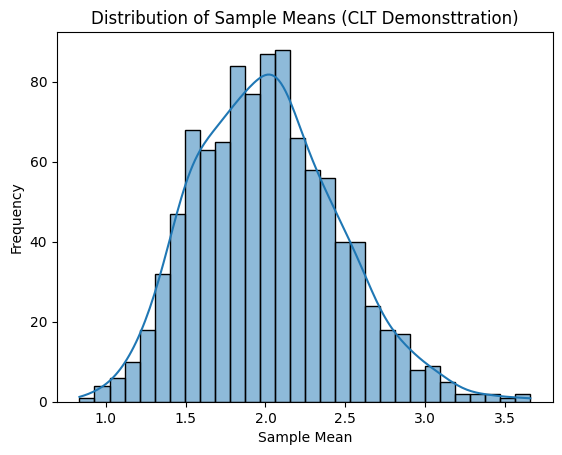

In [8]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
population = np.random.exponential(scale=2.0, size=100000)
sample_means = []
for _ in range(1000) : 
    sample = np.random.choice(population, size=20)
    sample_means.append(np.mean(sample))

plt.figure()
sns.histplot(sample_means, bins = 30, kde=True)
plt.title("Distribution of Sample Means (CLT Demonsttration)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

# Q.2
- Objective: Compare the effect of different sample sizes on the distribution of sample means.
### **Task Steps:**
1. Use the same population from Lab 1.
2. Repeat CLT for sample sizes 10, 30, and 50.
3. Plot and compare the histograms of sample means for each.
4. Observe how increasing sample size affects normality.

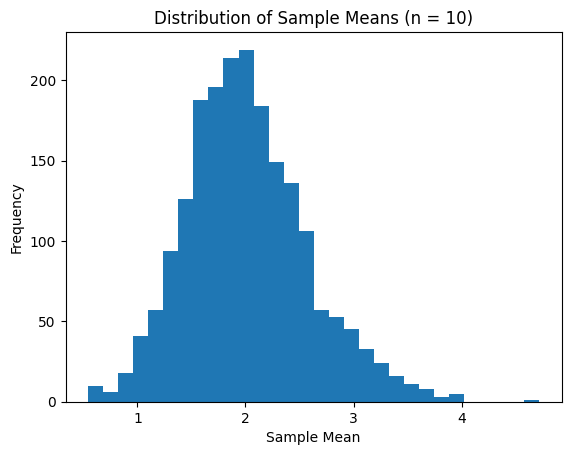

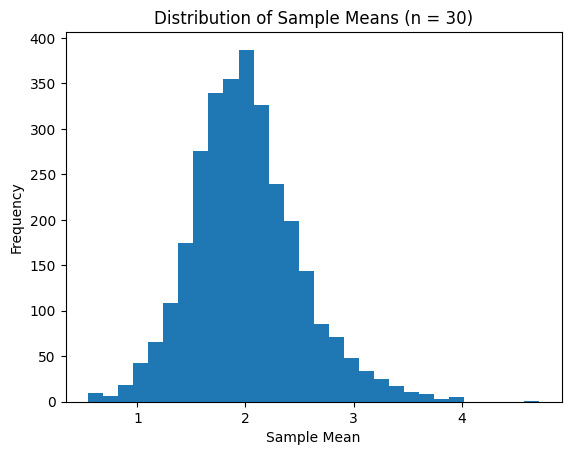

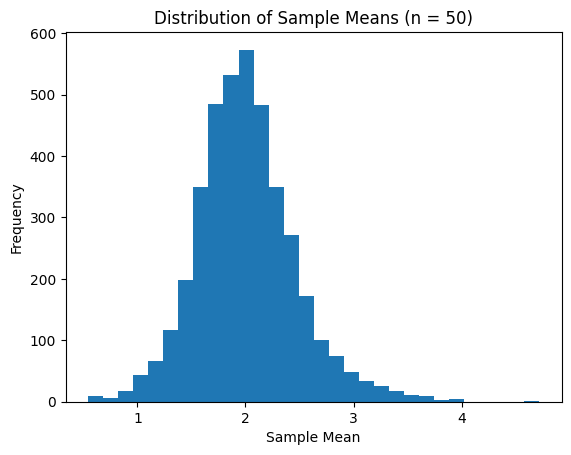

In [9]:
population = np.random.exponential(scale=2.0, size=100000)
sample_sizes = [10,30,50]
num_samples = 1000

for n in sample_sizes :
    sample_menas = []
    for _ in range(num_samples): 
        sample = np.random.choice(population, size=n)
        sample_means.append(np.mean(sample))

    plt.figure()
    plt.hist(sample_means, bins=30)
    plt.title(f"Distribution of Sample Means (n = {n})")
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.show()



# Q.3
- **Objective:** Check whether a dice is fair based on observed frequencies.
### Task Steps:
1. Simulate rolling a dice 120 times and record the frequency of each face.
2. Assume the expected frequency is equal for all faces (1-6).
3. Perform a chi-square goodness of fit test.
4. Report the chi-square value and p-value.

In [19]:
from scipy.stats import chisquare

print("H0: The dice is fair (all faces have equal probability).")
print("H1: The dice is NOT fair (at least one face has different probability).")

np.random.seed(42)
rolls = np.random.randint(1, 7, size=120)

observed_freq =  []
for i in range(1, 7):
    count = np.sum(rolls == i)
    observed_freq.append(count)

observed_freq = np.array(observed_freq)
print("Observed frequencies:", observed_freq)


expected_freq = np.array([20] * 6)
print("Expected frequencies : ",expected_freq)

chi2_stat, p_value = chisquare(f_obs= observed_freq, f_exp= expected_freq)
print(f"\nChi-square statistics : {chi2_stat:.4f}")
print(f"p-value : {p_value:.4f}")

alpha = 0.05
if p_value < alpha : 
    print("Rejet H0 : The dice is NOT fair.")
else : 
    print("Fail to reject H0 : The dice is fair.")
    

H0: The dice is fair (all faces have equal probability).
H1: The dice is NOT fair (at least one face has different probability).
Observed frequencies: [19 21 16 28 19 17]
Expected frequencies :  [20 20 20 20 20 20]

Chi-square statistics : 4.6000
p-value : 0.4666
Fail to reject H0 : The dice is fair.


# Q.4
- **Objective:** Check if there is any relationship between gender and preferred movie genre.
- **Task Steps:**
1. Create a 2x3 contingency table: Gender (Male, Female) vs Genre (Action, Comedy, Drama).
2. Use dummy values to fill the table.
3. Perform a chi-square test of independence.
4. Report the chi-square value and p-value.

In [32]:
from scipy.stats import chi2


print("\nH0: Gender and preferred movie genre are independent (no relationship).")
print("H1: Gender and preferred movie genre are not independent (there is a relationship).")

# chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
# print(f"\nChi-square statistic: {chi2_stat:.4f}")
# print(f"P-value: {p_value:.4f}")
# print(f"Degrees of freedom: {dof}")
# print("Expected frequencies:\n", expected)

observed = np.array([[20, 15, 10],
                     [10, 25, 15]])
print("Observed frequencies:\n", observed)

row_sums = observed.sum(axis=1)
col_sums = observed.sum(axis=0)
total = observed.sum()

print("\nRow sums:", row_sums)
print("Column sums:", col_sums)
print("Total:", total)

excepted = np.zeros_like(observed,dtype=float)
for i in range(observed.shape[0]): 
    for j in range(observed.shape[1]):
        expected[i,j] = row_sums[i] * col_sums[j] / total 
print("\nExpected frequencies:\n", expected)

chi2_stat = 0
for i in range(observed.shape[0]) :
    for j in range(observed.shape[1]) : 
        chi2_stat +=  (observed[i, j] - expected[i, j])**2 / expected[i,j]
print(f"\n Chi-square statistics : {chi2_stat:.4f}")

dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)
alpha = 0.05
print("Degrees of freedom:", dof)

p_value = 1 - chi2.cdf(chi2_stat, dof)
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print("Conclusion: Reject H0 → There is a relationship between gender and preferred movie genre.")
else:
    print("Conclusion: Fail to reject H0 → No evidence of a relationship.")


H0: Gender and preferred movie genre are independent (no relationship).
H1: Gender and preferred movie genre are not independent (there is a relationship).
Observed frequencies:
 [[20 15 10]
 [10 25 15]]

Row sums: [45 50]
Column sums: [30 40 25]
Total: 95

Expected frequencies:
 [[14.21052632 18.94736842 11.84210526]
 [15.78947368 21.05263158 13.15789474]]

 Chi-square statistics : 6.5884
Degrees of freedom: 2
P-value: 0.0371
Conclusion: Reject H0 → There is a relationship between gender and preferred movie genre.


# Q.5
- **Objective:** Determine if there's a relationship between education level and daily internet usage.
### **Task Steps:**
- Create a contingency table with Education Levels (School, Graduate, Postgraduate) vs Internet Usage (Low, Medium, High).
- Fill it with dummy observed values.
- Perform a chi-square test of independence.
- Report the chi-square statistic and p-value.




In [33]:
import numpy as np
from scipy.stats import chi2

# Observed frequencies: Education Level vs Internet Usage
observed = np.array([[15, 20, 10],
                     [10, 25, 20],
                     [5, 10, 15]])
print("Observed frequencies:\n", observed)

# Hypotheses
print("\nH0: Education level and daily internet usage are independent (no relationship).")
print("H1: Education level and daily internet usage are not independent (there is a relationship).")

# Row sums, column sums, total
row_sums = observed.sum(axis=1)
col_sums = observed.sum(axis=0)
total = observed.sum()
print("\nRow sums:", row_sums)
print("Column sums:", col_sums)
print("Total:", total)

# Expected frequencies
expected = np.zeros_like(observed, dtype=float)
for i in range(observed.shape[0]):
    for j in range(observed.shape[1]):
        expected[i, j] = row_sums[i] * col_sums[j] / total
print("\nExpected frequencies:\n", expected)

# Chi-square statistic
chi2_stat = 0
for i in range(observed.shape[0]):
    for j in range(observed.shape[1]):
        chi2_stat += (observed[i, j] - expected[i, j])**2 / expected[i, j]
print(f"\nChi-square statistic: {chi2_stat:.4f}")

# Degrees of freedom, p-value, conclusion
dof = (observed.shape[0]-1)*(observed.shape[1]-1)
alpha = 0.05
p_value = 1 - chi2.cdf(chi2_stat, dof)
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print("Conclusion: Reject H0 → There is a relationship between education level and daily internet usage.")
else:
    print("Conclusion: Fail to reject H0 → No evidence of a relationship.")


Observed frequencies:
 [[15 20 10]
 [10 25 20]
 [ 5 10 15]]

H0: Education level and daily internet usage are independent (no relationship).
H1: Education level and daily internet usage are not independent (there is a relationship).

Row sums: [45 55 30]
Column sums: [30 55 45]
Total: 130

Expected frequencies:
 [[10.38461538 19.03846154 15.57692308]
 [12.69230769 23.26923077 19.03846154]
 [ 6.92307692 12.69230769 10.38461538]]

Chi-square statistic: 8.0015
Degrees of freedom: 4
P-value: 0.0915
Conclusion: Fail to reject H0 → No evidence of a relationship.


# Q.6
### **Objective:** Check whether food preferences vary by age group.
#### **Task Steps:**
1. Construct a 3x3 contingency table with Age Groups (Teens, Adults, Seniors) and Food Types (Veg, Non-Veg, Mixed).
2. Use sample counts to fill the table.
3. Apply a chi-square test of independence.
4. Record the chi-square statistic and p-value.


In [39]:
# Contingency table: Age Group vs Food Type
observed = np.array([[15, 20, 10],   # Teens
                     [25, 15, 20],   # Adults
                     [10, 5, 15]])   # Seniors

# Chi-Square Test of Independence
chi2_stat, p_value, dof, expected = chi2_contingency(observed)

# Output results
print("Chi-square statistic:", chi2_stat)
print("P-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)

# Conclusion at alpha = 0.05
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject H0 → Food preferences vary by age group.")
else:
    print("Conclusion: Fail to reject H0 → No evidence that food preferences vary by age group.")

Chi-square statistic: 10.260416666666668
P-value: 0.03626219290991761
Degrees of freedom: 4
Expected frequencies:
 [[16.66666667 13.33333333 15.        ]
 [22.22222222 17.77777778 20.        ]
 [11.11111111  8.88888889 10.        ]]
Conclusion: Reject H0 → Food preferences vary by age group.
